In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

## Walmart

!Question Exam June 2024!

Below are Wal-Mart's quarterly sales (expressed in billion dollars)
1. Convert the “startdate” to the datatype datetime.
2. Create the plot below.

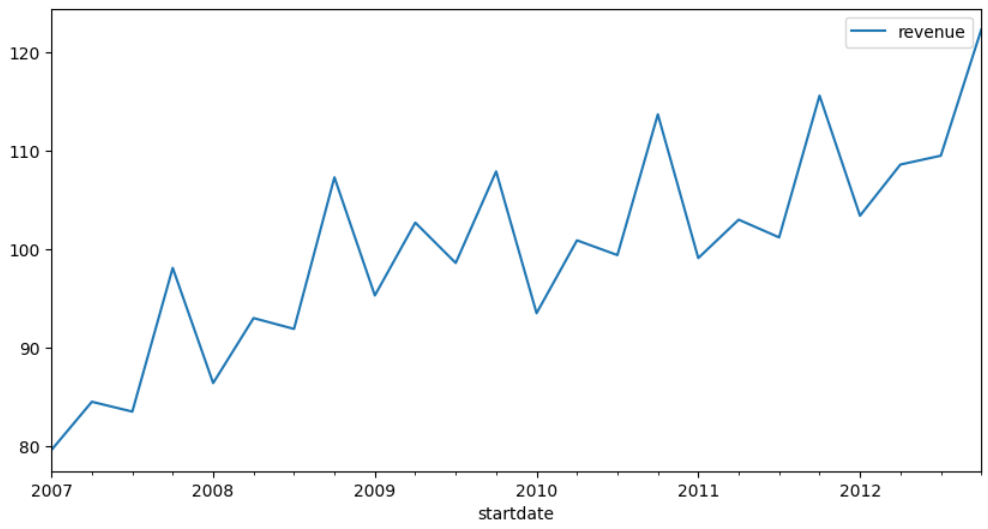

3. Make a forecast for next accounting year's sales using the most appropriate method. Explain why you chose this method.
4. Make a plot including the forecast for the next accounting year.
5. In which quarter will sales exceed $150 billion for the first time? [2018-10-01]

In [12]:
dfwalmart = pd.DataFrame(data={
    'startdate': ['2007/01/01', '2007/04/01', '2007/07/01', '2007/10/01', '2008/01/01', '2008/04/01', '2008/07/01', '2008/10/01','2009/01/01', '2009/04/01', '2009/07/01', '2009/10/01','2010/01/01', '2010/04/01', '2010/07/01', '2010/10/01','2011/01/01', '2011/04/01', '2011/07/01', '2011/10/01','2012/01/01', '2012/04/01', '2012/07/01', '2012/10/01'],
    'quarter': ['2007-1','2007-2','2007-3','2007-4','2008-1','2008-2','2008-3','2008-4','2009-1','2009-2','2009-3','2009-4','2010-1','2010-2','2010-3','2010-4','2011-1','2011-2','2011-3','2011-4','2012-1','2011-2','2011-3','2011-4'],
    'revenue': [79.6,84.5,83.5,98.1,86.4,93,91.9,107.3,95.3,102.7,98.6,107.9,93.5,100.9,99.4,113.7,99.1,103,101.2,115.6,103.4,108.6,109.5,122.3]
})

dfwalmart.head()

,startdate,quarter,revenue
0,2007/01/01,2007-1,79.6
1,2007/04/01,2007-2,84.5
2,2007/07/01,2007-3,83.5
3,2007/10/01,2007-4,98.1
4,2008/01/01,2008-1,86.4


In [13]:
# 1. Convert the “startdate” to the datatype datetime.

dfwalmart['startdate'] = pd.to_datetime(dfwalmart['startdate'])
dfwalmart = dfwalmart.set_index('startdate')
dfwalmart.head(4)

,quarter,revenue
startdate,,
2007-01-01,2007-1,79.6
2007-04-01,2007-2,84.5
2007-07-01,2007-3,83.5
2007-10-01,2007-4,98.1


<Axes: xlabel='startdate'>

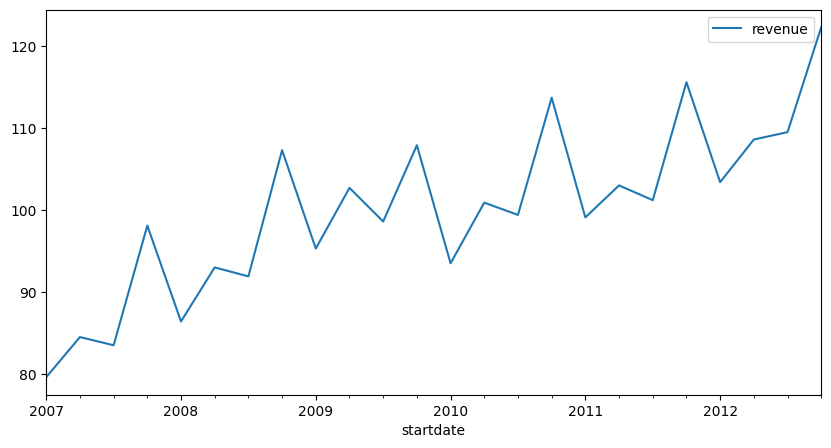

In [23]:
# 2. Create the plot below.
dfwalmart.plot(y='revenue',figsize=[10,5])
# dfwalmart[:'2009-12-01'].plot(y='revenue',figsize=[10,5])

In [25]:
# 3. Make a forecast for next accounting year's sales using the most appropriate method. Explain why you chose this method.

from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Multiplicative + QS!
data_tes = ExponentialSmoothing(dfwalmart['revenue'], trend='add', seasonal='add', seasonal_periods=4, freq='QS').fit()
data_tes_fc = data_tes.forecast(4)


<Axes: xlabel='startdate'>

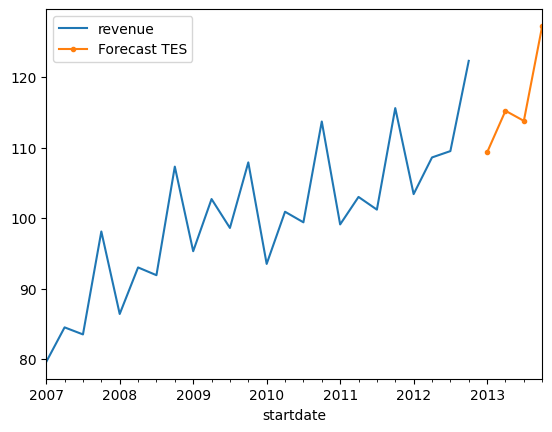

In [27]:
# 4.Make a plot including the forecast for the next accounting year.
dfwalmart['revenue'].plot(legend=True)
data_tes_fc.plot(marker='.', legend=True, label='Forecast TES')

In [56]:
# 5. In which quarter will sales exceed $150 billion for the first time?
data_tes_fc = data_tes.forecast(30)
data_tes_fc[data_tes_fc > 150]

,0
2018-10-01,152.020001
2019-10-01,156.973335
